<h4>Základné prvky R Markdown</h4>
        <table class="table table-bordered table-striped">
          <thead>
            <tr><th>kód</th><th> Popis</th></tr>
          </thead>
          <tbody>          
            <tr>
              <td class="text-nowrap"><code>*italic*</code>alebo <code>  _italic_ </code></td>
              <td>Šikmé písmo</td>
            </tr>
            <tr>
              <td class="text-nowrap"><code>**bold**</code> alebo <code>__bold__</code> </td>
              <td>Tučné písmo</td>
            </tr>
            <tr>
              <td class="text-nowrap"><code>~~slovo~~</code></td>
              <td>Prečiarknuté písmo</td>
            </tr>
            <tr>
              <td class="text-nowrap">
                <p><code> # Header 1 </code></p>
                <p><code>## Header 2 </code></p>
                <p><code>### Header 3</code></p>
              <td>Nadpisy</td>
            </tr>
            <tr>
              <td class="text-nowrap">
                <p><code> - Item 1</code></p>
                <p><code> - Item 2</code></p>
                <p><code> - Item 3</code></p>
              </td>
              <td>Jednoduchý nečíslovaný zoznam</td>
            </tr>
            <tr>
              <td class="text-nowrap">
                <p><code> * Item 1</code></p>
                <p><code> * Item 2</code></p>
                <p><code> [tab] * Item 2a</code></p>
                <p><code> [tab][tab] * Item 2b</code></p>
              </td>
              <td>Nečíslovaný zoznam</td>
            </tr>
            <tr>
              <td class="text-nowrap">
                <p><code> 1. Item 1</code></p>
                <p><code> 2. Item 2</code></p>
                <p><code> [tab] + Item 2a</code></p>
                <p><code> [tab][tab] + Item 2b</code></p>
              </td>
              <td>Číslovaný zoznam</td>
            </tr>
            <tr>
              <td class="text-nowrap"><code> http://example.com</code></td>
              <td>Link, priamo</td>
            </tr> 
            <tr>
              <td class="text-nowrap"><code> [moj text](http://example.com)</code></td>
              <td>Link s vloženým textom</td>
            </tr>
            <tr>
              <td class="text-nowrap"><code> [![moj text](http://example.com/logo.png)</code> <p>alebo</p> <p><code> ![moj text](figures/img.png)</code></p></td>
              <td>Odkaz na obrázok</td>
            </tr>
            <tr>
              <td class="text-nowrap"><code> > Toto je citácia v bloku</code></td>
              <td>Text (citácia) zarovnaná do bloku</td>
            </tr>
            <tr>
              <td class="text-nowrap"><code>***</code></td>
              <td>Horizontálna čiara</td>
            </tr>
            <tr>
              <td class="text-nowrap">
                <p><code> Názov 1 | Názov 2 | Názov 3</code></p>
                <p><code> ------- | ------- | -------</code></p>
                <p><code> Hodnota 1.1 | Hodnota 1.2 | Hodnota 1.3</code></p>
                <p><code> Hodnota 2.1 | Hodnota 2.2 | Hodnota 2.3</code></p>
              </td>
              <td>Tabuľky</td>
            </tr>
          </tbody>
        </table>

# R Shiny

Shiny je platforma pre vytváranie interaktívnych R programov vložených do web stránok

## Základné funkcie 

Vstupy `Input()` a výstupy `Output()` zadávame do skriptu *ui.R*.

Ako sa má vypísať (renderovať) výsledok určíme pomocou funkcie `render()` v skripte *server.R*, pričom sa na vstupy a výstupy odkazujeme pomocou znaku  `$`, napríklad `output$premenná`. Kód serverovej funkcie obalíme do `render*` funkcie pred uložením výsledku

<ul>
<li><h4>Vstupy od používateľa</h4></li>
<p><img class="img-responsive center-block"  alt="" src="https://datalab.kkui.fei.tuke.sk/www/JDA/cvi%C4%8Denia%20R/img/shiny-input.png"   width="660" height="600"> </p>
<li><h4>Výstupné a renderovacie funkcie</h4></li>
<p><img class="img-responsive center-block"  src="https://datalab.kkui.fei.tuke.sk/www/JDA/cvi%C4%8Denia%20R/img/shiny-output.png"   width="660" height="600">  </p>
<li><h4>Celkový vzhľad stránky</h4></li>
<p><img class="img-responsive center-block"  src="https://datalab.kkui.fei.tuke.sk/www/JDA/cvi%C4%8Denia%20R/img/shiny-layout.png"  width="660" height="600">  </p>
<p>Viac v <a href="https://shiny.rstudio.com/images/shiny-cheatsheet.pdf " >  Rshiny Cheat Sheet </a>.</p>
</ul>

# Hello Shiny!

V nasledujúcich častiach podrobne rozoberieme vzorový kód a vysvetlíme použitie „reaktívnych“ prvkov na generovanie výstupu. Zatiaľ sa však skúste "hrať" s ukážkovou aplikáciou a sledujte zdrojový kód, aby ste získali prvotný prvotný prehľad. Nezabudnite si pozorne prečítať komentáre.

Zdrojové súbory R Shiny aplikácie je potrebné umiestniť do adresára `/work/aplikacia/`. 
Log z aplikácie je uložený v adresári `/logs/`.
Používateľské rozhranie je definované v zdrojovom súbore s názvom `ui.R`:

``` R
library(shiny)

# Definujte UI pre aplikáciu, ktorá vykresľuje náhodné distribúcie 
shinyUI(fluidPage(

  # Titulok
  headerPanel("Hello Shiny!"),
  
  # Panel s posuvným vstupom pre počet pozorovaní = slider
  sidebarPanel(
    sliderInput("obs", 
                "Number of observations:", 
                min = 1,
                max = 1000, 
                value = 500)
  ),

    # Zobraziť graf generovanej distribúcie  mainPanel(
    plotOutput("distPlot")
  )
)
```

V `server.R` sa generuje náhodná distribúcia s požadovaným počtom pozorovaní a potom sa vynesie do grafu ako histogram. Všimnite si však aj to, že funkcia, ktorá vracia graf, je zabalená do funkcie `renderPlot`.

``` R
library(shiny)
# Definujte logiku servera potrebnú na vygenerovanie a vykreslenie náhodnej distribúcie
shinyServer(function(input, output) { 
   # Výraz, ktorý generuje graf distribúcie.
   # Tento vyraz je "zabaleny" do renderPlot, čo znamená, že:
   #      1) Je „reaktívny“, a preto by mal byť automaticky
   #         znovu vykonaný pri zmene vstupov
   #      2) Výstup je graf
    output$distPlot <- renderPlot({
    # vygeneruje rnorm rozdelenie a vykreslí ho
    dist <- rnorm(input$obs)
    hist(dist)
  })
})
```

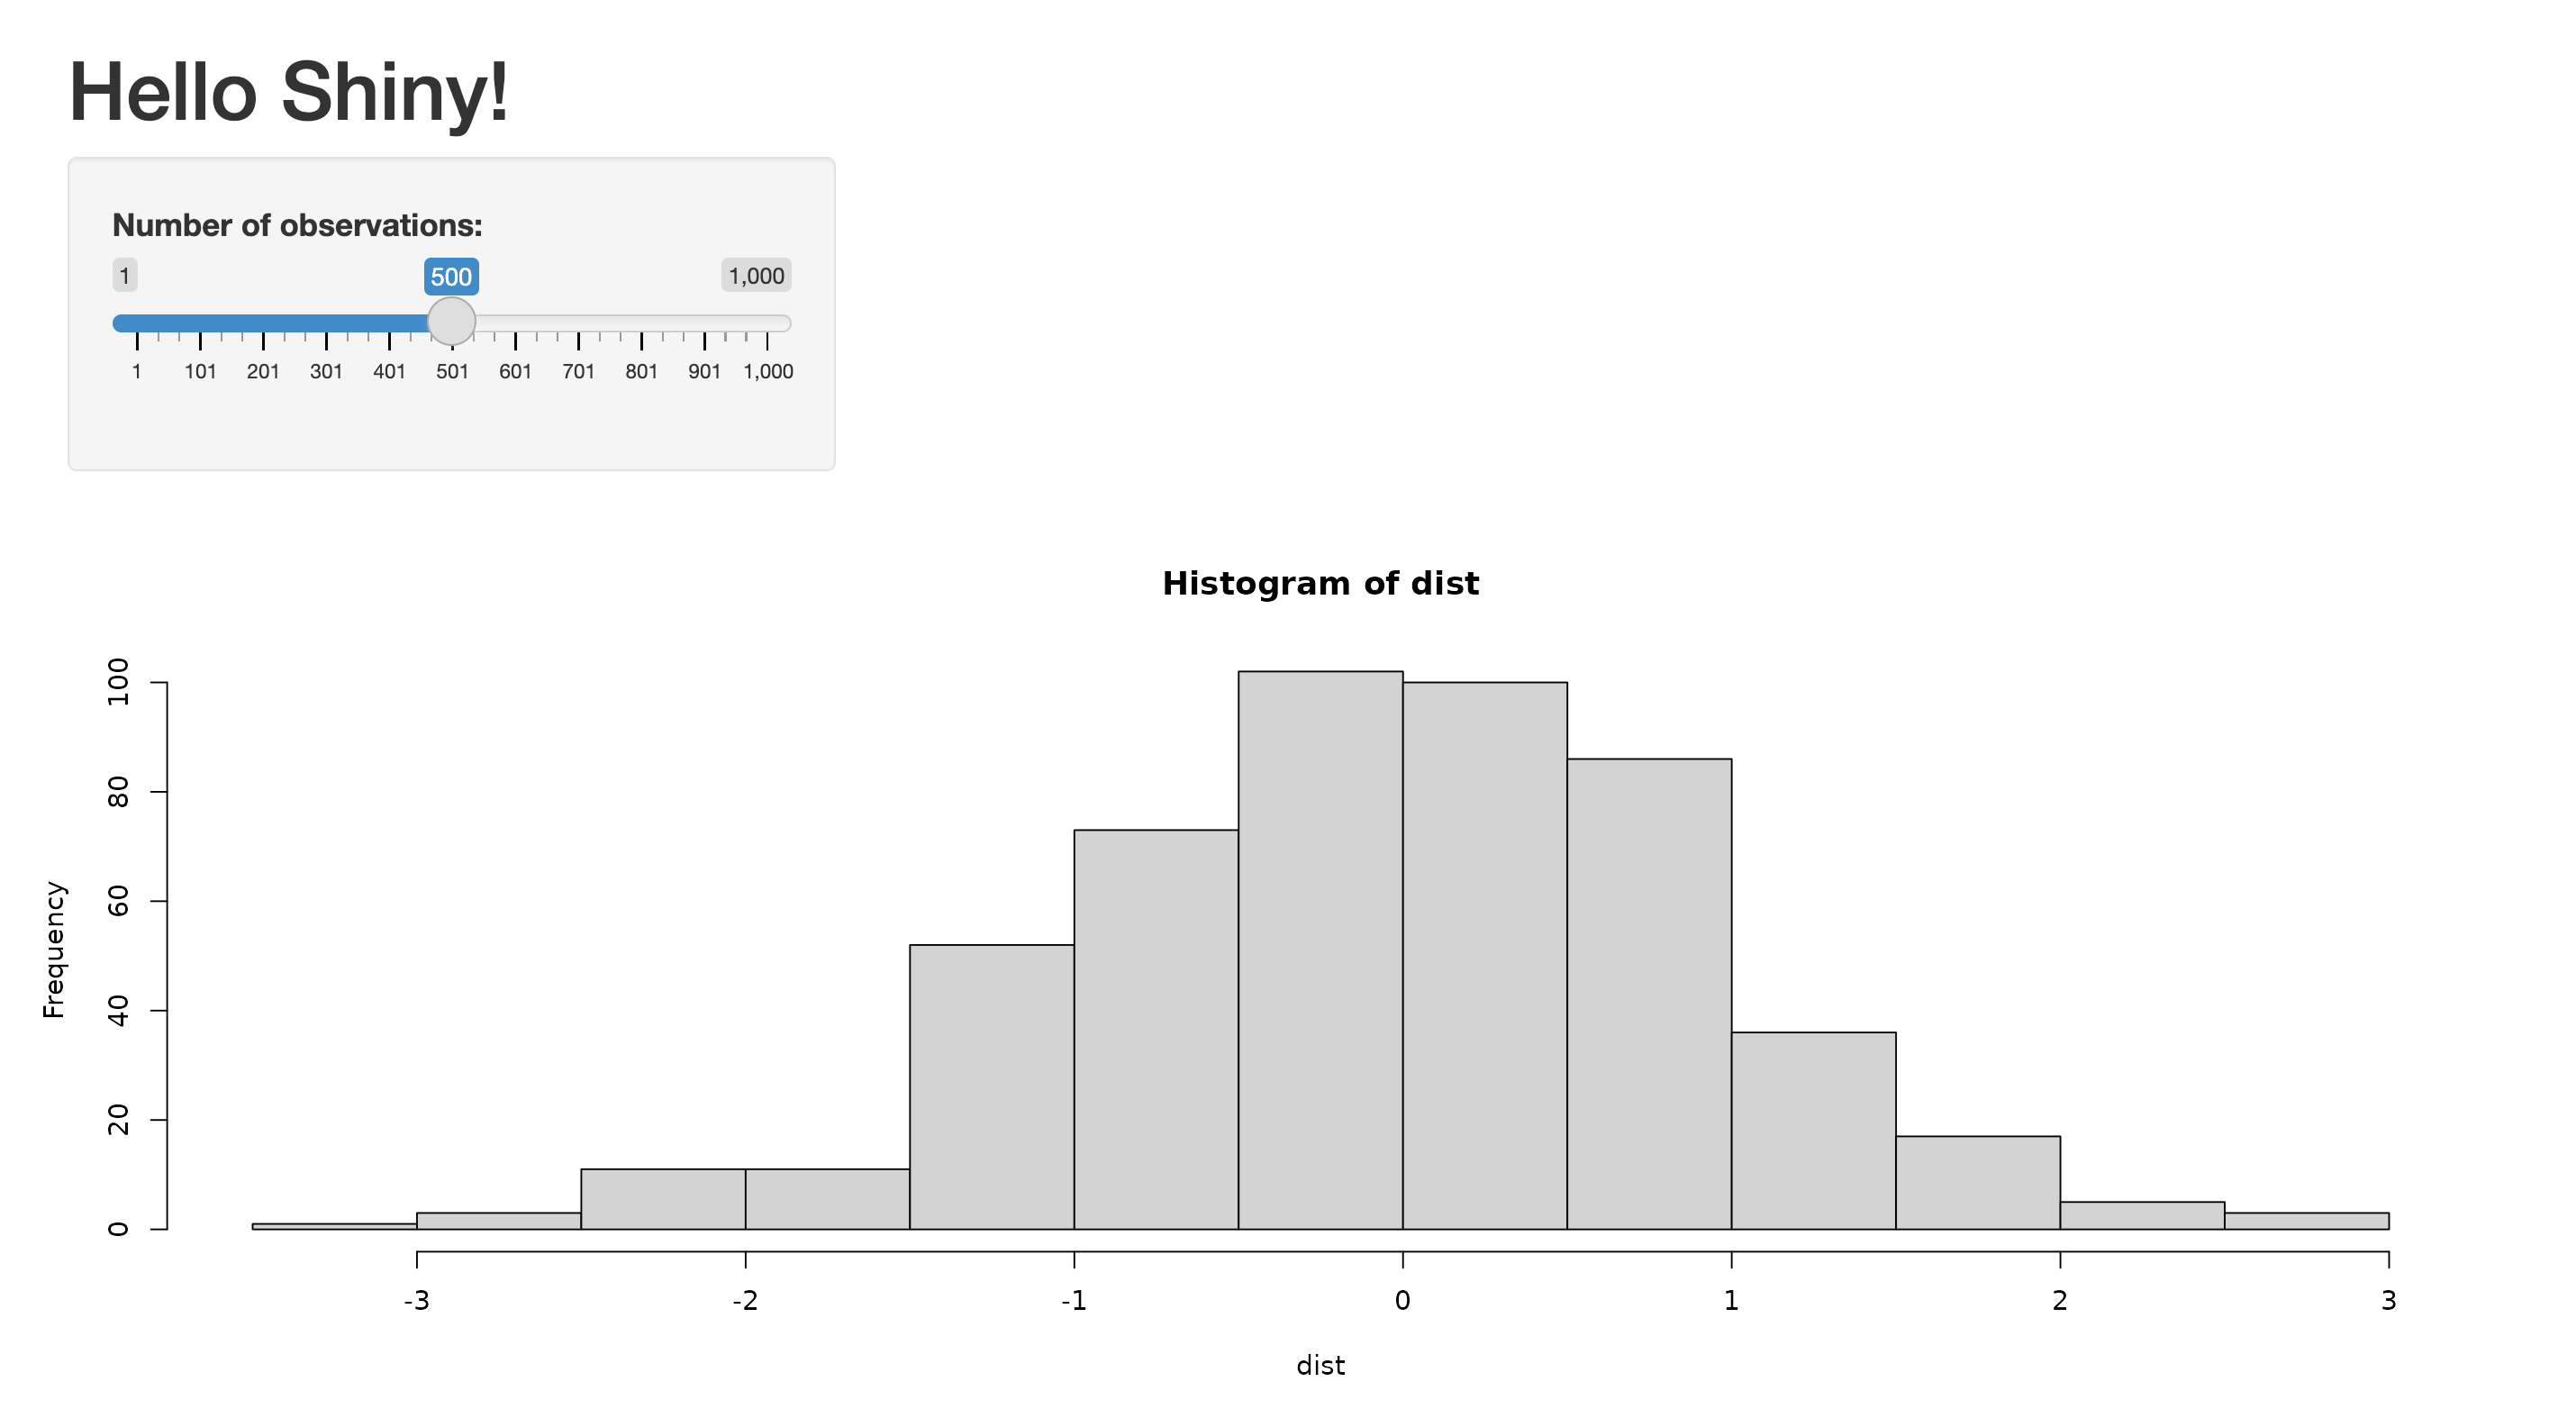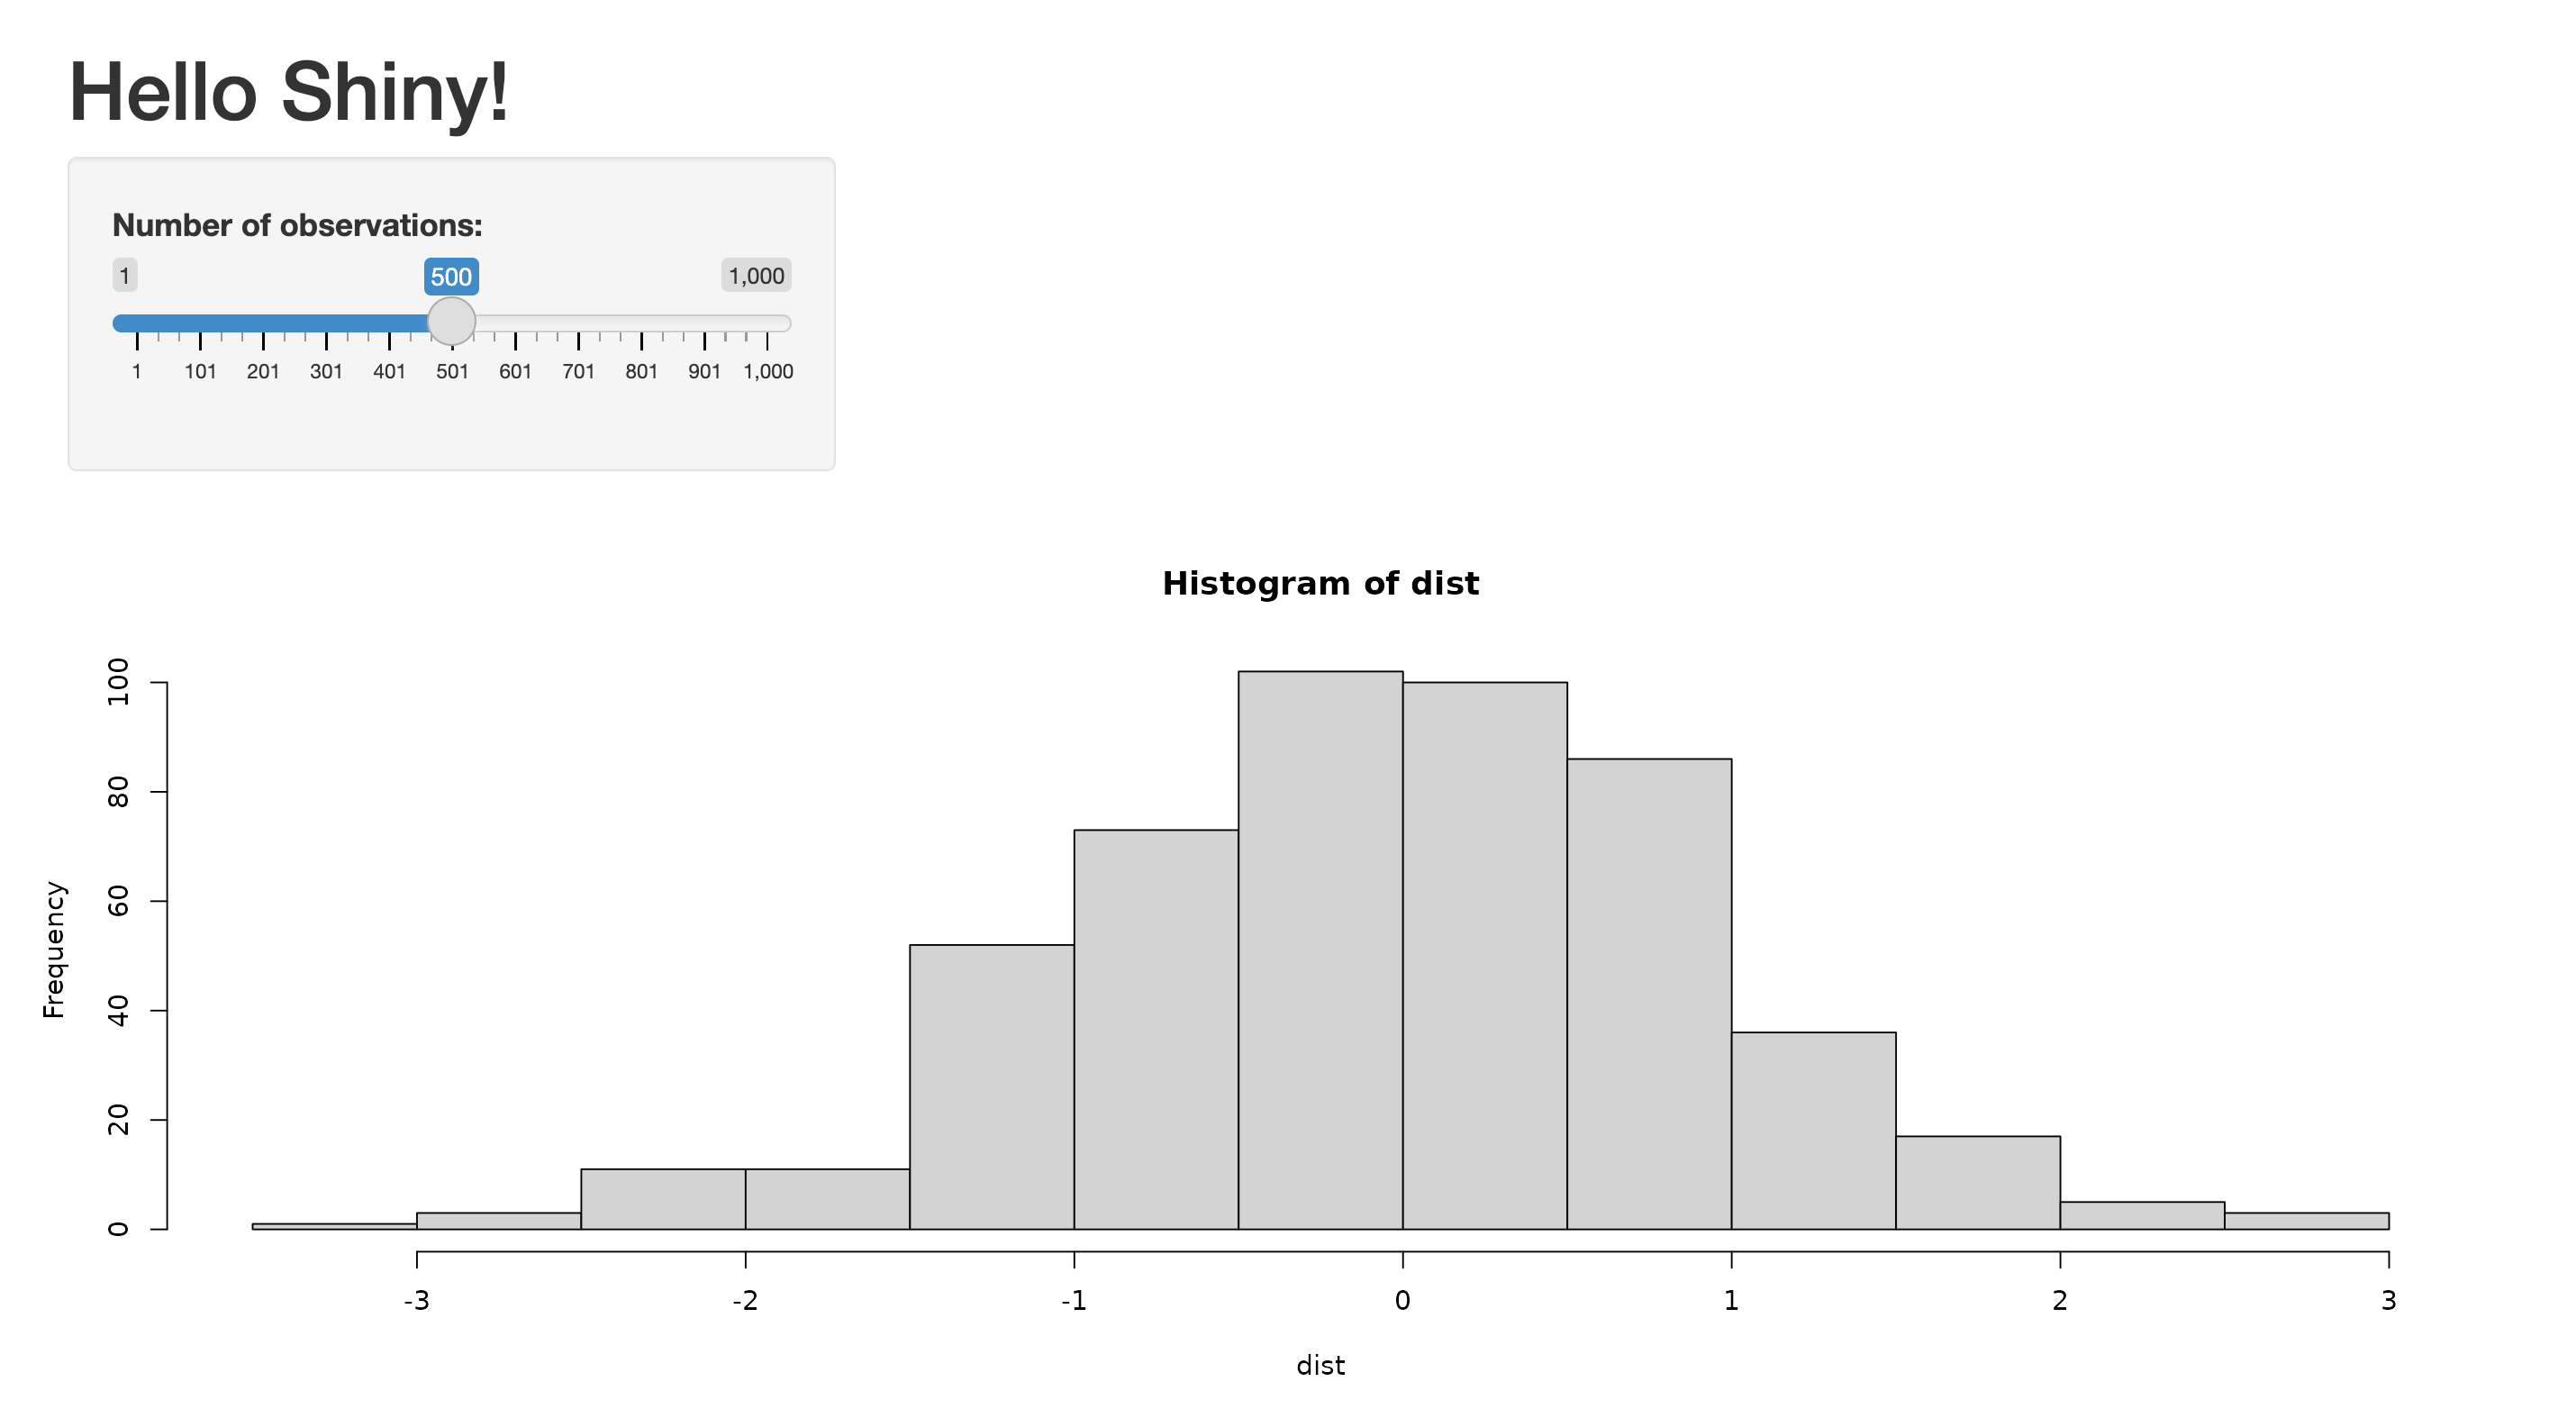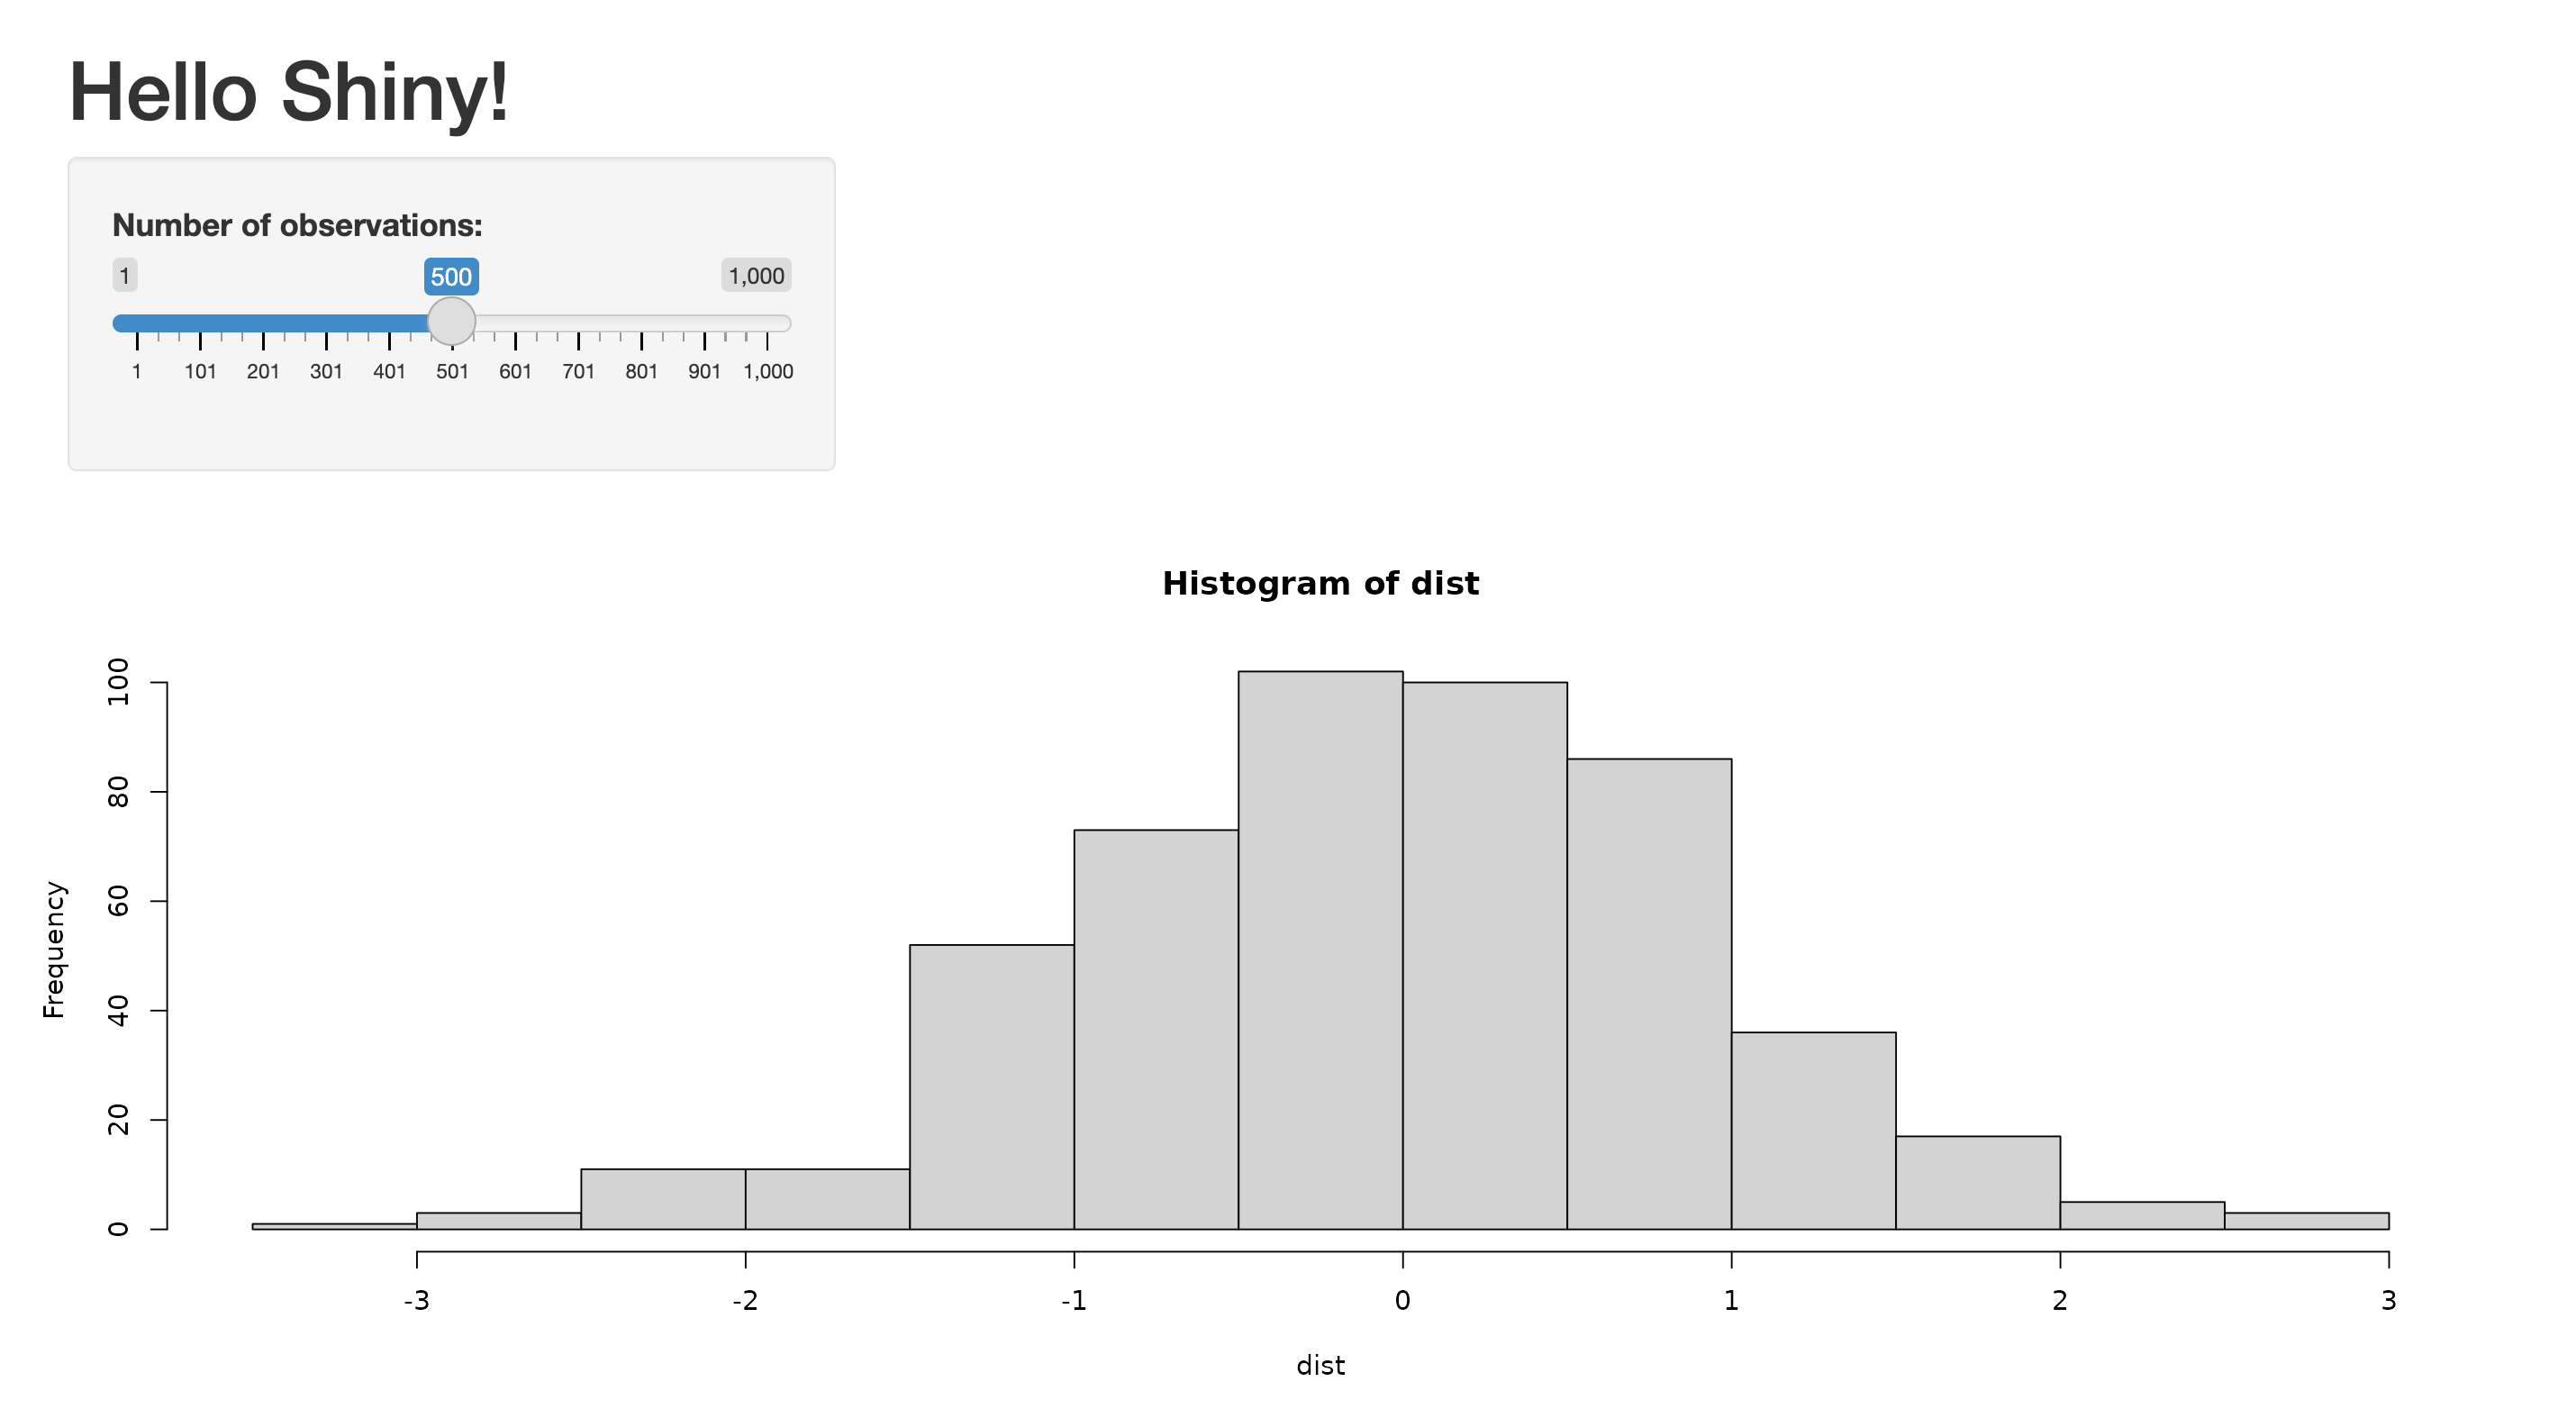Výsledná aplikácia bude vyzerať nasledovne:

![alt text](https://datalab.kkui.fei.tuke.sk/www/JDA/cvi%C4%8Denia%20R/img/shiny-hello.png "Title")

# Shiny príklad 2
Nasledújci príklad ukáže použitie väčšieho množstva vstupných ovládacích prvkov, ako aj použitie reaktívnych funkcií na generovanie textového výstupu.

Prvý príklad mal zadaný jeden číselný vstup pomocou slider-a a jedného výstupu grafu. Tento príklad má o niečo viac: dva vstupy a dva typy textového výstupu.

Ak sa pokúsite zmeniť počet pozorovaní na inú hodnotu, uvidíte ukážku jedného z najdôležitejších vlastností Shiny aplikácií: vstupy a výstupy sú navzájom prepojené a zmeny sa okamžite šíria. V tomto prípade sa namiesto opätovného načítania celej stránky aktualizuje iba zobrazenie tabuľky, keď sa zmení počet pozorovaní.



Všimnite si, že v `ui.R` funkcie `sidebarPanel` a `mainPanel` sa teraz volajú s dvoma argumentmi (zodpovedajúcimi zobrazeným dvom vstupom a dvom výstupom):

``` R
library(shiny)

shinyUI(fluidPage(

  # Titulok
  headerPanel("Shiny Text"),

  # Sidebar s ovládacími prvkami na výber množiny údajov 
  # a určenie počtu pozorovaní, ktoré sa majú zobraziť
  sidebarPanel(
    selectInput("dataset", "Choose a dataset:", 
                choices = c("rock", "pressure", "cars")),

    numericInput("obs", "Number of observations to view:", 10)
  ),

  # Zobraziť sumárnu tabuľku s požadovaným počťom pozorovaní
  mainPanel(
    verbatimTextOutput("summary"),

    tableOutput("view")
  )
))
```

Serverová časť aplikácie sa tiež trochu skomplikovala. Teraz vytvárame:

- Reaktívny prvok na vrátenie množiny údajov zodpovedajúcej voľbe užívateľa
- Dva ďalšie vykresľovacie výrazy `renderPrint` a `renderTable`, ktoré vracajú `output$summary` a `output$view` hodnoty

Tieto výrazy fungujú podobne ako `renderPlot` výraz použitý v prvom príklade: deklarovaním vykresľovacieho výrazu zadáme, že by sa zmena mala vykonať, len keď sa zmení jeho závislosť. V tomto prípade je to buď jedna z užívateľských vstupných hodnôt `input$dataset` alebo `input$n`).

``` R
library(shiny)
library(datasets)

# Definujte logiku servera potrebnú na zhrnutie a zobrazenie vybraného súboru údajov
shinyServer(function(input, output) {

  # Vráti požadovaný súbor údajov
  datasetInput <- reactive({
    switch(input$dataset,
           "rock" = rock,
           "pressure" = pressure,
           "cars" = cars)
  })

  # Vytvorte sumarizáciu údajov
  output$summary <- renderPrint({
    dataset <- datasetInput()
    summary(dataset)
  })

  # Zobrazte prvých "n" pozorovaní
  output$view <- renderTable({
    head(datasetInput(), n = input$obs)
  })
})
```

Výsledná aplikácia bude vyzerať nasledovne:

![alt text](https://datalab.kkui.fei.tuke.sk/www/JDA/cvi%C4%8Denia%20R/img/shiny-priklad2.png "Title")

# Shiny príklad 3

Zaviedli sme využívanie reaktívnych výrazov, zatiaľ sme však nevysvetľovali, ako fungujú. Predchadzajúci príklad rozšírime o ďalšie reaktívne prvky aby sme pochopili ako fungujú v Shiny. Keďže sú Shiny webové aplikácie interaktívne, vstupné hodnoty sa môžu kedykoľvek zmeniť a výstupné hodnoty sa musia okamžite aktualizovať, aby odrážali tieto zmeny.



``` R
library(shiny)

shinyUI(fluidPage(
  # nadpis
  headerPanel("Reactivity"),
  # SLider panel s ovládacími prvkami, ktorý poskytuje popis, 
  # vyberte množinu údajov a zadajte počet pozorovaní, ktoré sa majú zobraziť.
  # Všimnite si, že zmeny vykonané v popise v text Input sa aktualizujú okamžite pri písaní
  sidebarPanel(
    textInput("caption", "Caption:", "Data Summary"),

    selectInput("dataset", "Choose a dataset:", 
                choices = c("rock", "pressure", "cars")),

    numericInput("obs", "Number of observations to view:", 10)
  ),

  # Zobrazí nadpis, sumárnu tabuľku s požadovaným počtom pozorovaní
  mainPanel(
    h3(textOutput("caption")), 

    verbatimTextOutput("summary"), 

    tableOutput("view")
  )
))
```

Serverový skript deklaruje `datasetInput` reaktívny výraz, ako aj tri hodnoty reaktívneho výstupu. Pre každú definíciu sú podrobné poznámky, ktoré popisujú, ako to funguje v reaktívnom systéme:

```R
library(shiny)
library(datasets)

# Definujte logiku servera potrebnú na zhrnutie a zobrazenie vybraného súboru údajov

shinyServer(function(input, output) {

  # Ak označíme datasetInput ako reaktívny, zabezpečíme že:
  #
  #  1) Zavolá sa iba vtedy, keď vstupy závisia od zmien
  #  2) Výpočet a výsledok zdieľajú všetci volajúci (vykoná sa naraz)
  
  datasetInput <- reactive({
    switch(input$dataset,
           "rock" = rock,
           "pressure" = pressure,
           "cars" = cars)
  })

  #  output$caption sa počíta na základe reaktívneho výrazu, ktorý
  # vráti input$caption. Ak používateľ zmení "caption":
  #
  #  1) tento výraz sa automaticky zavolá aby sa výstup prekompiloval 
  #  2) Nový nadpis sa zobrazí v prehliadači
  
  output$caption <- renderText({
    input$caption
  })

  # output$summary je závislí od datasetInput reaktívneho výrazu, 
  # takže bude znova vykonaný vždy, keď sa zmenia vstupné údaje
  
  output$summary <- renderPrint({
    dataset <- datasetInput()
    summary(dataset)
  })

  # output$view závisí na dvoch reaktívnych výrayoch a to databaseInput
  # a input$obs, takže sa znova vykoná vždy, keď sa zmení input$dataset  
  # alebo input$obs. 
  
  output$view <- renderTable({
    head(datasetInput(), n = input$obs)
  })
})
```

Výsledná aplikácia bude vyzerať nasledovne:

![alt text](https://datalab.kkui.fei.tuke.sk/www/JDA/cvi%C4%8Denia%20R/img/shiny-reactivity.png "Title")

# Shiny príklad 4

Reaktivitu výrazov vieme v rámci Shiny aplikácie obmedzovať. V tomto príklade si ukážeme ako môžeme reaktivitu obmedziť len na stlačenie akčného tlačítka.

``` R
library(shiny)

shinyUI(fluidPage(
  headerPanel("Action button"),
  
    sidebarPanel(   
        # Vstupy v rámci sidebaru vieme zoskupiť. Vhodné použitie zoskupenia je s akčným tlačítkom.
        # V prípade použitia akčného tlačítka v rámci zoskúpenia sa očakáva že program bude reagovať na zmeny 
        # vstupu až po aktivácii akčného tlačítka.
    wellPanel(
    selectInput("atribut", "Vyberte atribút:", 
                choices = c("cyl", "gear")),
        numericInput("numinput", "Líniová čiara v grafe", 1, 1, 10, 2),
        actionButton("action", "Spusť")
  )
  ),
  
  mainPanel(
    plotOutput("graf")
  )
))
```

Serverový skript obsahuje funkcie `observeEvent()` ktorá reaguje na vstup z akčného tlačítka a `isolate()` ktorý obmedzuje reaktivitu vnoreného bloku kódu.

``` R
library(shiny)
library(datasets)


shinyServer(function(input, output) {
  
  atributInput <- reactive({
    switch(input$atribut,
           "cyl" = mtcars$cyl,
           "gear" = mtcars$gear)
  })
 
 # Zavolanie funkcie observeEvent ktorú aktivuje akčné tlačidlo
 observeEvent(input$action, {
  output$graf = renderPlot({
      # Funkcia izolovania reaktitivy zabezpečí, že obsah v rámci funkcie je vykonaný až na základe akcie (observeEvent)
      isolate({
             barplot(table(atributInput()), main=input$caption)
             abline(h = input$numinput, lwd=2, col="black")
                  })
          })
     })
  
})
```

Výsledná aplikácia bude vyzerať nasledovne:

![alt text](https://datalab.kkui.fei.tuke.sk/www/JDA/cvi%C4%8Denia%20R/img/shiny-action-button.png "Title")

<div class="alert alert-info">
  <h4>Úloha 5.1</h4>
  <p>
Vytvorte <samp>RShiny</samp> aplikáciu, ktorá bude obsahovať nadpis („<b>Dáta Airquality</b>“). V <samp>UI.R</samp> nastavte vzhľad RShiny aplikácie, ktorá bude mať tieto vstupy: </p>
    <ul>
     
<li>	<code>NumericInput</code> s textom („<b>Počet riadkov tabuľky</b>“), kde preddefinovaná hodnota bude 6, minimálna 1, maximálna 100 a krok nastavte na 5.</li>
<li>	Nasledujúce vstupné elementy (<code>selectInput, radioButtons, textInput, actionButton</code>) zgrupte do jednej skupiny.</li>
<li>	<code>SelectInput</code>, s textom („<b>Vyberte atribút</b>“), možnosti budú všetky názvy stĺpcov dát airquality. </li>
<li>	<code>RadioButtons</code>s textom („<b>Vyberte farbu grafu</b>“), s možnosťami zelená, žltá.</li>
<li>	<code>TextInput</code> s textom („<b>Zadajte nadpis grafu</b>:“), kde preddefinovaná hodnota bude „<b>Nadpis</b>“. </li>
<li>	<code>ActionButton</code>, pomocou ktorého sa zmeny vo výstupnom grafe vykonajú až po kliknutí na neho.</li>
<li>	V <code>mainPanel</code> vypíšte výstupy v poradí tabuľka, graf a text (veta). </li>
</ul>
<p>V <samp>SERVER.R</samp> vytvorte kódy pre vytvorenie: </p>

<p><ul>
<li>	Grafu z dát <b>airquality</b>, v ktorom bude zobrazený stĺpec vybraný na vstupe <code>SelectInput</code> v závislosti od stĺpca Month. Tento graf bude <code>boxplot</code>, farba nastavte podľa vstupu <code>RadioButton</code> a pridajte nadpis zo vstupu <code>TextInput</code>. Pri zmene vstupov sa graf zmení až po kliknutí na tlačidlo <code>ActionButton</code>.</li>
<li>	Výpisu tabuľky, ktorá bude obsahovať dáta <b>airquality</b>, pričom bude zobrazený iba určitý počet riadkov podľa <code>NumericInputu</code> (zobrazenie len posledných <samp>n</samp> riadkov tabuľky).</li>
<li>	Výpis normálneho textu napr. „<b>Zobrazili ste tabuľku s 5 riadkami a boxplot pre atribút Ozone ste nastavili na farbu green</b>“. Počet riadkov (v tomto prípade 5), atribút (Ozone) a farba grafu (green) sa bude meniť podľa zvolených vstupov.</li>
</ul></p>
<p><img class="img-responsive center-block" alt=""  src="https://datalab.kkui.fei.tuke.sk/www/JDA/cvi%C4%8Denia%20R/img/uloha5.1.png"  width="600" height="220"> </p>
</div>

## Ďalšie úlohy na precvičenie R Shiny

1. Vytvorte aplikáciu, ktorá zobrazuje tabuľku s datasetom `mtcars`. Používateľ by mal byť schopný zvoliť, ktoré stĺpce z datasetu zobrazí. Aplikácia by mala umožniť používateľovi aj zoraďovanie podľa zvoleného stĺpca a vyhľadávanie záznamu v tabuľke.

2. Vytvorte aplikáciu, ktorá zobrazuje grafické zobrazenie z datasetu `iris`. Používateľ by mal byť schopný zvoliť, ktoré premenné z datasetu použije pre x a y osi. Aplikácia by mala umožniť používateľovi zmeniť nadpis grafu a nastaviť názvy osí po stlačení tlačidla.

3. Vytvorte aplikáciu, ktorá zobrazuje mapu s geografickými dátami z datasetu `quakes`. Používateľ by mal byť schopný zvoliť, ktorú stanicu `stations` zobrazí na mape. Aplikácia by mala umožniť používateľovi zobraziť zvolený počet náhodných riadkov tabuľky, až po stlačení tlačítka `Spusť`.

4. Vytvorte aplikáciu, ktorá zobrazuje histogram dát z datasetu `airquality`. Používateľ by mal byť schopný zvoliť, ktorú premennú z datasetu použije pre zobrazenie histogramu a nastaviť počet skupín. Aplikácia by mala umožniť používateľovi aj zmeniť farebné rozlíšenie histogramu a nastaviť popisky osí a názov grafu. 